In [1]:
# ============================================================
# FUNCTION 6 — WEEK 5 CLEAN REBUILD
# ============================================================

import numpy as np

from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    ConstantKernel as C,
    Matern,
    WhiteKernel
)

# ------------------------------------------------------------
# 1. Load the original Function 6 data
# ------------------------------------------------------------

X = np.load("function6/initial_inputs.npy")
Y = np.load("function6/initial_outputs.npy").reshape(-1)

# ------------------------------------------------------------
# 2. Add Weeks 1–4 exactly once
# ------------------------------------------------------------

week1_x = np.array([[
    0.296485,
    0.322087,
    0.332446,
    0.760368,
    0.040944
]])

week1_y = np.array([
    -0.5070321901597052
])

week2_x = np.array([[
    0.351404,
    0.334902,
    0.511830,
    0.859800,
    0.149390
]])

week2_y = np.array([
    -0.39798887850658554
])

week3_x = np.array([[
    0.469953,
    0.133458,
    0.475744,
    0.973553,
    0.000000
]])

week3_y = np.array([
    -0.862627252477251
])

week4_x = np.array([[
    0.442929,
    0.409333,
    0.631830,
    0.739800,
    0.129381
]])

week4_y = np.array([
    -0.19517557780237038
])

X = np.vstack([
    X,
    week1_x,
    week2_x,
    week3_x,
    week4_x
])

Y = np.concatenate([
    Y,
    week1_y,
    week2_y,
    week3_y,
    week4_y
])

best_index = np.argmax(Y)
best_x = X[best_index]
best_y = Y[best_index]

print("X shape:", X.shape)
print("Y shape:", Y.shape)

print("\nBest observed input:", best_x)
print("Best observed output:", best_y)

# ------------------------------------------------------------
# 3. Fit an ARD Gaussian Process
# ------------------------------------------------------------

kernel = (
    C(1.0, (1e-3, 1e3))
    * Matern(
        length_scale=np.array([
            0.50,
            0.50,
            0.70,
            0.60,
            0.50
        ]),
        length_scale_bounds=(0.02, 3.0),
        nu=2.5
    )
    + WhiteKernel(
        noise_level=1e-6,
        noise_level_bounds=(1e-10, 1e-2)
    )
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=25,
    random_state=56
)

gp.fit(X, Y)

print("\nFitted kernel:")
print(gp.kernel_)

# ------------------------------------------------------------
# 4. Inspect the fitted lengthscales
# ------------------------------------------------------------

lengthscales = np.asarray(
    gp.kernel_.k1.k2.length_scale
)

importance = 1 / lengthscales
importance = importance / importance.sum()

print("\nFitted lengthscales:", lengthscales)
print("Normalised input influence:")

for i, value in enumerate(importance, start=1):
    print(f"x{i}: {value:.4f}")

# ------------------------------------------------------------
# 5. Generate Week 5 candidates
#
# Week 4 improved strongly, so most candidates are close to
# the Week 4 point. Different search widths are used for each
# dimension rather than moving all five variables equally.
# ------------------------------------------------------------

rng = np.random.default_rng(56)

very_local = rng.normal(
    loc=best_x,
    scale=[
        0.012,
        0.012,
        0.015,
        0.012,
        0.010
    ],
    size=(20_000, 5)
)

local = rng.normal(
    loc=best_x,
    scale=[
        0.035,
        0.035,
        0.045,
        0.035,
        0.030
    ],
    size=(20_000, 5)
)

wider_local = rng.normal(
    loc=best_x,
    scale=[
        0.080,
        0.080,
        0.100,
        0.080,
        0.070
    ],
    size=(12_000, 5)
)

# Search between Week 2 and Week 4 because both were useful
blend_weights = rng.uniform(
    0,
    1,
    size=(10_000, 1)
)

blended_candidates = (
    blend_weights * week2_x
    + (1 - blend_weights) * week4_x
)

blended_candidates += rng.normal(
    loc=0,
    scale=[
        0.020,
        0.020,
        0.025,
        0.020,
        0.015
    ],
    size=(10_000, 5)
)

# Keep a limited amount of global exploration
global_candidates = rng.uniform(
    0,
    1,
    size=(5_000, 5)
)

candidates = np.vstack([
    very_local,
    local,
    wider_local,
    blended_candidates,
    global_candidates
])

candidates = np.clip(candidates, 0, 1)

# ------------------------------------------------------------
# 6. Remove candidates that nearly repeat existing points
# ------------------------------------------------------------

distances = np.linalg.norm(
    candidates[:, None, :] - X[None, :, :],
    axis=2
)

minimum_distance = distances.min(axis=1)

candidates = candidates[
    minimum_distance > 0.004
]

# ------------------------------------------------------------
# 7. Predict candidate performance
# ------------------------------------------------------------

mean, std = gp.predict(
    candidates,
    return_std=True
)

# ------------------------------------------------------------
# 8. Expected Improvement
# ------------------------------------------------------------

xi = 0.002

improvement = mean - best_y - xi

with np.errstate(divide="ignore", invalid="ignore"):
    z = improvement / std

    expected_improvement = (
        improvement * norm.cdf(z)
        + std * norm.pdf(z)
    )

expected_improvement[std < 1e-12] = 0

# ------------------------------------------------------------
# 9. Upper Confidence Bound
# ------------------------------------------------------------

# Week 4 succeeded, so exploration is now moderate rather
# than aggressive.
kappa = 0.60

ucb = mean + kappa * std

# ------------------------------------------------------------
# 10. Filter out clearly weak predicted candidates
# ------------------------------------------------------------

mean_filter = mean >= (best_y - 0.10)

if np.sum(mean_filter) < 100:
    mean_filter = mean >= np.percentile(mean, 90)

filtered_candidates = candidates[mean_filter]
filtered_mean = mean[mean_filter]
filtered_std = std[mean_filter]
filtered_ei = expected_improvement[mean_filter]
filtered_ucb = ucb[mean_filter]

# ------------------------------------------------------------
# 11. Combine EI and UCB
# ------------------------------------------------------------

ei_normalised = (
    filtered_ei - filtered_ei.min()
) / (
    filtered_ei.max()
    - filtered_ei.min()
    + 1e-12
)

ucb_normalised = (
    filtered_ucb - filtered_ucb.min()
) / (
    filtered_ucb.max()
    - filtered_ucb.min()
    + 1e-12
)

# Stronger emphasis on exploitation after the Week 4 success
acquisition = (
    0.78 * ei_normalised
    + 0.22 * ucb_normalised
)

best_candidate_index = np.argmax(acquisition)
week5_query = filtered_candidates[best_candidate_index]

# ------------------------------------------------------------
# 12. Print the Week 5 proposal
# ------------------------------------------------------------

print("\nMethod:")
print("Local filtered Expected Improvement with moderate UCB")

print("\nCandidates passing mean filter:",
      len(filtered_candidates))

print("\nSuggested Week 5 query:")
print(week5_query)

print("\nPortal format:")
print("-".join(
    f"{value:.6f}"
    for value in week5_query
))

print("\nPredicted mean:",
      filtered_mean[best_candidate_index])

print("Predicted standard deviation:",
      filtered_std[best_candidate_index])

print("Expected Improvement:",
      filtered_ei[best_candidate_index])

print("UCB:",
      filtered_ucb[best_candidate_index])

print("Distance from Week 4 point:",
      np.linalg.norm(
          week5_query - week4_x[0]
      ))

print("Distance from Week 2 point:",
      np.linalg.norm(
          week5_query - week2_x[0]
      ))

X shape: (24, 5)
Y shape: (24,)

Best observed input: [0.442929 0.409333 0.63183  0.7398   0.129381]
Best observed output: -0.19517557780237038

Fitted kernel:
1.35**2 * Matern(length_scale=[0.707, 0.818, 1.53, 0.899, 0.966], nu=2.5) + WhiteKernel(noise_level=1.6e-10)

Fitted lengthscales: [0.70732307 0.81823253 1.52543568 0.89862631 0.96566579]
Normalised input influence:
x1: 0.2599
x2: 0.2247
x3: 0.1205
x4: 0.2046
x5: 0.1904

Method:
Local filtered Expected Improvement with moderate UCB

Candidates passing mean filter: 52266

Suggested Week 5 query:
[0.46059235 0.37037048 0.86337216 0.65801631 0.09598583]

Portal format:
0.460592-0.370370-0.863372-0.658016-0.095986

Predicted mean: -0.18370793099195026
Predicted standard deviation: 0.10061466132084611
Expected Improvement: 0.04505084115570364
UCB: -0.1233391341994426
Distance from Week 4 point: 0.25148688576353295
Distance from Week 2 point: 0.4246535810551768


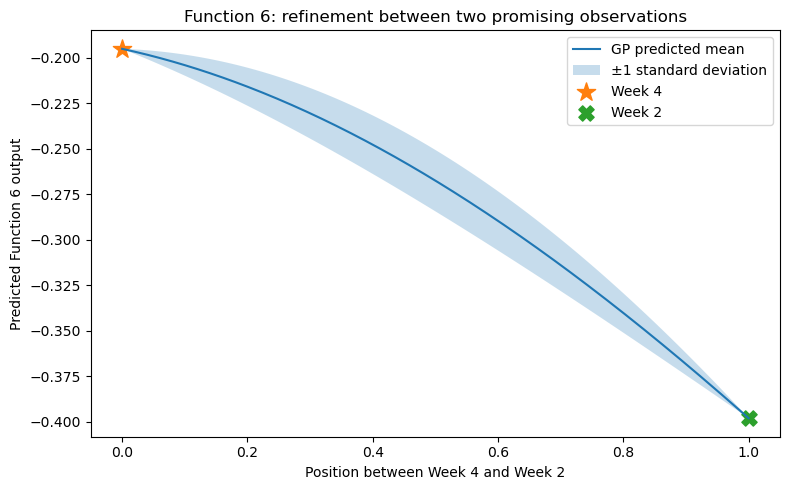

In [2]:
# ------------------------------------------------------------
# 13. Plot the path between Week 2 and Week 4
# ------------------------------------------------------------

import matplotlib.pyplot as plt

path_weights = np.linspace(0, 1, 300)

path_points = (
    path_weights[:, None] * week2_x
    + (1 - path_weights[:, None]) * week4_x
)

path_mean, path_std = gp.predict(
    path_points,
    return_std=True
)

plt.figure(figsize=(8, 5))

plt.plot(
    path_weights,
    path_mean,
    label="GP predicted mean"
)

plt.fill_between(
    path_weights,
    path_mean - path_std,
    path_mean + path_std,
    alpha=0.25,
    label="±1 standard deviation"
)

plt.scatter(
    0,
    week4_y[0],
    marker="*",
    s=190,
    label="Week 4"
)

plt.scatter(
    1,
    week2_y[0],
    marker="X",
    s=120,
    label="Week 2"
)

plt.xlabel("Position between Week 4 and Week 2")
plt.ylabel("Predicted Function 6 output")
plt.title("Function 6: refinement between two promising observations")
plt.legend()
plt.tight_layout()
plt.show()